Link presentación: https://docs.google.com/presentation/d/1GeX6IHyVrMSX91tuOPS1K9VsujEgh0Xw/edit?usp=sharing&ouid=116619599937703463090&rtpof=true&sd=true

link Dataset: https://drive.google.com/file/d/1TwS7C29QeNDgYC-iTlNppGn9V5zLfrZ2/view?usp=sharing

# Dataset ciclo de compras

El presente dataset fue generado mediante la herramienta Claude, con fines de análisis y práctica.

## Contexto de la empresa:
Razón social: Plastiandina Industrial S.A.S.

Actividad principal: Fabricación y distribución de empaques, piezas técnicas y componentes plásticos para los sectores de alimentos, construcción y manufactura. La compañía adquiere materia prima, insumos químicos, maquinaria y servicios de mantenimiento a través de un ciclo de compras centralizado, que involucra a más de 800 proveedores activos.


# Objetivo del análisis:

1.	Determinar cómo se comporta la cartera de cuentas por pagar en función de sus categorías y otros factores relevantes (montos, tiempos, proveedores y antigüedad).

2.	Identificar posibles patrones en dicho comportamiento que constituyan indicios de fraude.

#Análisis a realizar

Para dar cumplimiento a los objetivos planteados, se llevan a cabo los siguientes análisis sobre las variables del dataset:


In [51]:
# @title
# Plan de análisis: qué variable vamos a revisar y para qué

variables = [
    "neto_a_pagar",
    "numero_factura",
    "id_oc",
    "fecha_factura / estado",
    "hora_registro",
    "neto_a_pagar",
    "id_usuario_registro / id_aprobador",
    "hora_inusual / outliers_iqr / conflicto_intereses",
    "id_centro_costo / neto_a_pagar",
    "categoria / neto_a_pagar",
]

analisis = [
    "Estadística descriptiva general",
    "Identificación de facturas duplicadas",
    "Relación entre facturas y su respectiva orden de compra, identificando aquellas sin OC asociada",
    "Validación de antigüedad de cartera",
    "Identificación de registros en horarios inusuales",
    "Detección de valores atípicos (outliers)",
    "Verificación de que el usuario que registra y el que aprueba no coincidan",
    "Análisis comparativo cruzado entre estas variables",
    "Concentración de pagos por centro de costo",
    "Concentración de pagos por categoría",
]

plan_analisis = pd.DataFrame({
    "Variable(s)": variables,
    "Análisis a realizar": analisis
})

plan_analisis.index = plan_analisis.index + 1
plan_analisis

,Variable(s),Análisis a realizar
1,neto_a_pagar,Estadística descriptiva general
2,numero_factura,Identificación de facturas duplicadas
3,id_oc,Relación entre facturas y su respectiva orden ...
4,fecha_factura / estado,Validación de antigüedad de cartera
5,hora_registro,Identificación de registros en horarios inusuales
6,neto_a_pagar,Detección de valores atípicos (outliers)
7,id_usuario_registro / id_aprobador,Verificación de que el usuario que registra y ...
8,hora_inusual / outliers_iqr / conflicto_intereses,Análisis comparativo cruzado entre estas varia...
9,id_centro_costo / neto_a_pagar,Concentración de pagos por centro de costo
10,categoria / neto_a_pagar,Concentración de pagos por categoría


# Importar Librerias y Archivo a Analizar

In [2]:
import pandas as pd
import numpy as np
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/vista_analitica_facturas.csv')
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_comparte_direccion_con_empleado,perfil_comparte_telefono_con_empleado,perfil_cuenta_compartida_otro_proveedor,perfil_dias_creacion_a_primera_factura,perfil_alta_reciente_y_factura_inmediata,perfil_sin_contrato_alto_volumen,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48,44,34,...,0,0,0,2126,0,0,0,0.0000,1,Medio
1,2,F4216-78916,1,NaN,2023-04-29,2023-05-06,2023-05-08,08:15,246,144,...,0,0,0,2126,0,0,0,0.0000,1,Medio
2,3,F2076-18010,1,NaN,2023-10-27,2023-10-29,2023-10-30,09:35,271,157,...,0,0,0,2126,0,0,0,0.0000,1,Medio
3,4,F9288-76229,1,NaN,2024-08-24,2024-08-28,2024-09-05,08:05,14,240,...,0,0,0,2126,0,0,0,0.0000,1,Medio
4,5,F3400-6882,2,NaN,2024-07-14,2024-07-19,2024-07-30,15:21,122,17,...,0,0,0,1863,0,0,0,0.0282,3,Alto


# Analisis del tamaño, tipos de variables  y variables nulas del dataset

Empezamos revisando la estructura del dataset, su tamaño, el tipo de dato de
cada columna y la presencia de valores nulos. El objetivo es entender qué
información tenemos disponible y detectar desde el inicio qué campos van a
necesitar limpieza.

Trabajamos con 40.113 facturas y 94 columnas, que combinan variables
numéricas, fechas y texto.

In [3]:
df.shape

(40113, 94)

In [4]:
df.dtypes

,0
id_factura,int64
numero_factura,object
id_proveedor,int64
id_oc,float64
fecha_factura,object
...,...
perfil_sin_contrato_alto_volumen,int64
perfil_cambio_bancario_en_periodo,int64
perfil_creador_tambien_registra,float64
perfil_num_banderas_proveedor,int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40113 entries, 0 to 40112
Data columns (total 94 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   id_factura                                40113 non-null  int64  
 1   numero_factura                            40113 non-null  object 
 2   id_proveedor                              40113 non-null  int64  
 3   id_oc                                     21499 non-null  float64
 4   fecha_factura                             40113 non-null  object 
 5   fecha_recepcion                           40113 non-null  object 
 6   fecha_registro                            40113 non-null  object 
 7   hora_registro                             40113 non-null  object 
 8   id_usuario_registro                       40113 non-null  int64  
 9   id_aprobador                              40113 non-null  int64  
 10  id_centro_costo                   

# Tratamiento de la base de datos:

Se identificaron las facturas que no tienen una orden de compra (OC) asociada y se reemplazaron por la etiqueta "Sin_OC". Además, se convirtió el tipo de variable a string

In [6]:
df["id_oc"] = df["id_oc"].fillna("Sin_OC")

In [7]:
df["id_oc"] = df["id_oc"].astype(str)

Acá se cambió el tipo de datos de la columna " hora_registro" por un formato de hora.

In [8]:
# Se consultó en inteligencia artificial cómo aplicar formato de hora a la columna.
df['hora_registro'] = pd.to_datetime(df['hora_registro'], format='%H:%M').dt.time

Acá se cambió el tipo de datos de la columna "prov_fecha_creacion" por un formato de fecha

In [9]:
df['prov_fecha_creacion'] = pd.to_datetime(df['prov_fecha_creacion'])

# Analisis 1 - Neto a Pagar : Describe

El monto neto a pagar por factura oscila entre \$46.548 y \$2.186.393.290, con una media de \$12.243.939 muy por encima de la mediana (\$5.691.978).

Esta diferencia indica una distribución sesgada a la derecha: la mayoría de las facturas corresponden a montos moderados (75% son inferiores a \$12.341.115), pero un grupo reducido de facturas de muy alto valor como los pagos asociados a obras civiles eleva fuertemente el promedio y la desviación estándar (\$33.373.352).


In [10]:

df['neto_a_pagar'].describe().apply(lambda x: f"{x:,.0f}")

,neto_a_pagar
count,"40,113"
mean,"12,243,939"
std,"33,373,352"
min,"46,548"
25%,"2,633,823"
50%,"5,691,978"
75%,"12,341,115"
max,"2,186,393,290"


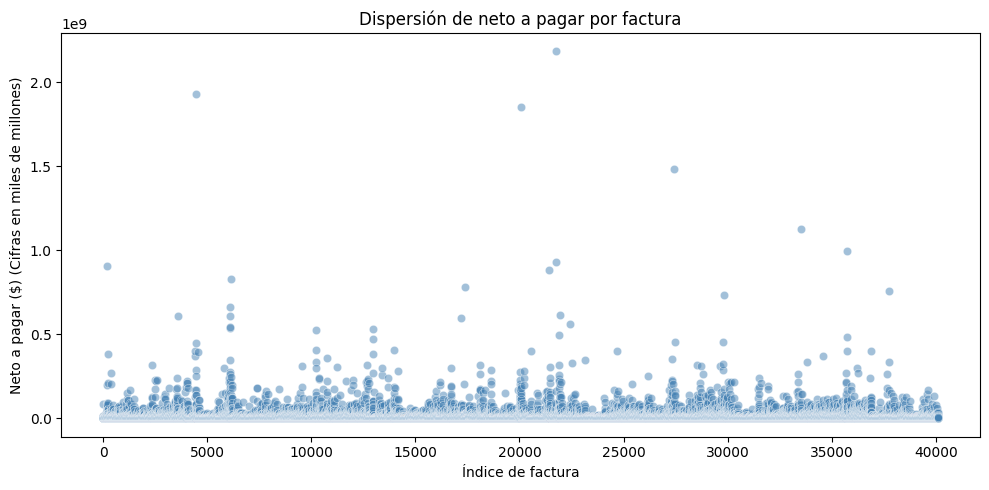

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df.index, y=df['neto_a_pagar'], alpha=0.5, color='steelblue')
plt.title('Dispersión de neto a pagar por factura')
plt.xlabel('Índice de factura')
plt.ylabel('Neto a pagar ($) (Cifras en miles de millones)')
plt.tight_layout()
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40113 entries, 0 to 40112
Data columns (total 94 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   id_factura                                40113 non-null  int64         
 1   numero_factura                            40113 non-null  object        
 2   id_proveedor                              40113 non-null  int64         
 3   id_oc                                     40113 non-null  object        
 4   fecha_factura                             40113 non-null  object        
 5   fecha_recepcion                           40113 non-null  object        
 6   fecha_registro                            40113 non-null  object        
 7   hora_registro                             40113 non-null  object        
 8   id_usuario_registro                       40113 non-null  int64         
 9   id_aprobador                

## Análisis 2 - numero_factura : Duplicados

Se identificaron 298 registros (149 números de factura distintos) marcados como duplicados, equivalentes al 0,74% del total de facturas. Aunque el porcentaje es bajo, el valor acumulado en juego asciende a \$3.286.523.370, una cifra material para efectos de control interno.

La existencia de números de factura repetidos puede explicarse por errores de digitación al registrar, pero también es una de las banderas clásicas de fraude por doble pago (recargar la misma factura dos veces, o registrar una factura legítima duplicada con leves variaciones para cobrar dos veces).

Este hallazgo justifica un cruce adicional entre número de factura, proveedor y monto para distinguir duplicados exactos de duplicados parciales (mismo número, distinto monto o distinta fecha).

In [13]:

df['es_duplicado'] = df.duplicated(subset='numero_factura', keep=False)
# La función Subset fue empleada tomando como referencia la revisión del material de la clase 8
df['es_duplicado'].value_counts()

,count
es_duplicado,
False,39815
True,298


## Análisis 3 — id_oc : Facturas sin orden de compra

El 46,4% de las facturas (18.614 de 40.113) no tiene una orden de compra asociada. Es una proporción muy alta: casi la mitad del gasto de la compañía se está causando sin el control previo que representa una OC (autorización, presupuesto y verificación de recepción del bien o servicio antes del pago).

Al cruzar esta variable con la etiqueta real de fraude del dataset (`es_fraude`), se observa que las facturas sin OC tienen una tasa de fraude de 4,7%, frente a solo 0,7% en las que sí cuentan con orden de compra: es decir, una factura sin OC tiene cerca de 6 veces más probabilidad de estar asociada a un esquema fraudulento.

Esto convierte la ausencia de orden de compra en uno de los indicadores más fuertes de riesgo dentro del ciclo de compras.

In [14]:

df["id_oc"].value_counts()

,count
id_oc,
Sin_OC,18614
11781.0,20
1599.0,15
4630.0,15
13850.0,15
...,...
12476.0,1
14375.0,1
716.0,1


In [15]:
df['id_oc'].value_counts(1)*100


,proportion
id_oc,
Sin_OC,46.403909
11781.0,0.049859
1599.0,0.037394
4630.0,0.037394
13850.0,0.037394
...,...
12476.0,0.002493
14375.0,0.002493
716.0,0.002493


## Análisis 4 — fecha_factura / estado : Antigüedad de la cartera

Del total de facturas, solo 1.106 (2,8%) permanecen en estado "Pendiente"; el resto ya fue pagado (38.702) o anulado (305), por lo que se clasifican automáticamente como "Sin vencer".

Al analizar exclusivamente las 1.106 facturas pendientes por su antigüedad frente a la fecha de corte (31-dic-2025), el panorama es preocupante: 647 de ellas (58,5% de las pendientes) caen en la categoría de mayor riesgo (más de 360 días), frente a apenas 133 en riesgo bajo.

En valor, la cartera pendiente se distribuye así:

| Categoría | Facturas | Valor | % del gasto total |
|---|---|---|---|
| Riesgo bajo (1-90 días) | 133 | \$1.505 millones | 0,31% |
| Riesgo moderado (91-180 días) | 106 | \$1.048 millones | 0,21% |
| Riesgo alto (181-360 días) | 220 | \$1.932 millones | 0,39% |
| Riesgo de incobrabilidad (+360 días) | 647 | \$7.503 millones | 1,53% |
| **Total pendiente** | **1.106** | **\$11.988 millones** | **2,44%** |

Frente al gasto total de la compañía (\$491.141 millones), el peso de la cartera vencida es marginal: apenas 2,44%. Pero su composición interna sí es una señal de alerta: el 63% de ese valor (\$7.503 de \$11.988 millones) está concentrado en facturas que llevan más de un año sin resolverse. Es decir, el problema no es el tamaño de la cartera pendiente sino su envejecimiento, lo que puede indicar cuellos de botella en el proceso de aprobación o disputas con proveedores no resueltas.

In [16]:
# Se utilizó el recurso de inteligencia aatificial para identificar una función que nos arroje el resultado de la antiguedad en días.

fecha_corte = pd.to_datetime("2025-12-31")
pendientes = df[df['estado'] == 'Pendiente'].copy()
pendientes['fecha_factura'] = pd.to_datetime(pendientes['fecha_factura'])
df["antiguedad_dias"] = pendientes['antiguedad_dias'] = (fecha_corte - pendientes['fecha_factura']).dt.days
df['antiguedad_dias'] = df['antiguedad_dias'].fillna(0)

In [17]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_cuenta_compartida_otro_proveedor,perfil_dias_creacion_a_primera_factura,perfil_alta_reciente_y_factura_inmediata,perfil_sin_contrato_alto_volumen,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,0,2126,0,0,0,0.0000,1,Medio,False,0.0
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,0,2126,0,0,0,0.0000,1,Medio,False,0.0
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,0,2126,0,0,0,0.0000,1,Medio,False,0.0
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,0,2126,0,0,0,0.0000,1,Medio,False,0.0
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,0,1863,0,0,0,0.0282,3,Alto,False,0.0


In [18]:
def clasificar_antiguedad(e):
    if e == 0:
        return "Sin vencer"
    elif 1 <= e <= 90:
        return "Riesgo bajo"
    elif 91 <= e <= 180:
        return "Riesgo moderado"
    elif 181 <= e <= 360:
        return "Riesgo alto"
    else:
        return "Riesgo de incobrabilidad"

df["estado_antiguedad"] = df["antiguedad_dias"].apply(clasificar_antiguedad)

In [19]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_dias_creacion_a_primera_factura,perfil_alta_reciente_y_factura_inmediata,perfil_sin_contrato_alto_volumen,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias,estado_antiguedad
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,2126,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,2126,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,2126,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,2126,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,1863,0,0,0,0.0282,3,Alto,False,0.0,Sin vencer


In [20]:
df.shape

(40113, 97)

In [21]:
df['estado_antiguedad'].value_counts()

,count
estado_antiguedad,
Sin vencer,39007
Riesgo de incobrabilidad,647
Riesgo alto,220
Riesgo bajo,133
Riesgo moderado,106


In [22]:
df['estado_antiguedad'].value_counts(1)*100

,proportion
estado_antiguedad,
Sin vencer,97.242789
Riesgo de incobrabilidad,1.612943
Riesgo alto,0.548451
Riesgo bajo,0.331563
Riesgo moderado,0.264253


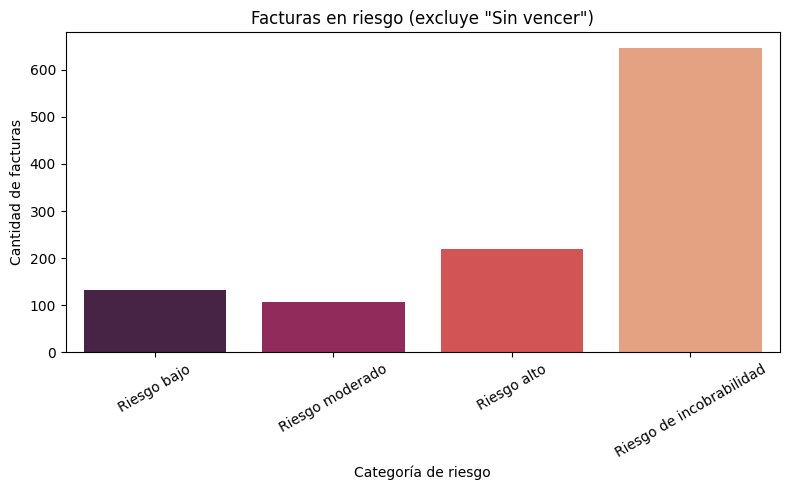

In [23]:
orden_riesgo = ["Riesgo bajo", "Riesgo moderado", "Riesgo alto", "Riesgo de incobrabilidad"]

conteo_riesgo = df[df['estado_antiguedad'] != 'Sin vencer']['estado_antiguedad'].value_counts().reindex(orden_riesgo).reset_index()
conteo_riesgo.columns = ['estado_antiguedad', 'cantidad_facturas']

plt.figure(figsize=(8, 5))
sns.barplot(data=conteo_riesgo, x='estado_antiguedad', y='cantidad_facturas',
            order=orden_riesgo, hue='estado_antiguedad', palette='rocket', legend=False)
plt.title('Facturas en riesgo (excluye "Sin vencer")')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Cantidad de facturas')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Análisis 5 — hora_registro : Horas inusuales

Se definió como "hora inusual" todo registro realizado fuera de la ventana 7:00 a.m.–7:00 p.m. Bajo este criterio, 1.828 facturas (4,56%) fueron registradas fuera del horario laboral típico. Es un porcentaje bajo pero no despreciable: casi 1 de cada 20 facturas se procesa de noche o de madrugada.

Registrar facturas fuera de horario no es evidencia de fraude por sí sola (puede deberse a cierres de mes, trabajo remoto o turnos especiales), pero sí es una condición que reduce la probabilidad de que otro empleado esté presente para ejercer control simultáneo, por lo que se usa como una de las tres señales que alimentan el indicador combinado más adelante.

In [24]:
inicio = pd.to_datetime('07:00').time()
fin = pd.to_datetime('19:00').time()
df['hora_inusual'] = ~df['hora_registro'].between(inicio, fin)



In [25]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_alta_reciente_y_factura_inmediata,perfil_sin_contrato_alto_volumen,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias,estado_antiguedad,hora_inusual
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,0,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,0,0,0,0.0282,3,Alto,False,0.0,Sin vencer,False


In [26]:
df['hora_inusual'].value_counts()

,count
hora_inusual,
False,38285
True,1828


In [27]:
df['hora_inusual'].value_counts(1)*100

,proportion
hora_inusual,
False,95.442874
True,4.557126


In [28]:
df.shape

(40113, 98)

## Análisis 6 — neto_a_pagar : Outliers (IQR)

Usando el criterio de rango intercuartílico (Q1=\$2.633.823, Q3=\$12.341.115, IQR=\$9.707.292), el límite superior de "normalidad" queda en \$26.902.054. Por encima de ese valor se identificaron 3.543 facturas (8,83% del total), es decir, casi 1 de cada 11 facturas está por encima de lo estadísticamente esperado.

Este porcentaje es más alto de lo habitual en un análisis de outliers (normalmente se esperaría un 1%-5% en una distribución con colas moderadas), lo que refuerza la lectura del análisis de `neto_a_pagar`: la cartera tiene una cola derecha larga y "pesada", con muchos montos grandes que merecen revisión puntual antes de asumir que todos corresponden a operaciones legítimas de alto valor (obras civiles, maquinaria, etc.).

In [29]:

q1 = df.neto_a_pagar.quantile(0.25)
q3 = df.neto_a_pagar.quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

df['outliers_iqr'] = (df.neto_a_pagar < limite_inf) | (df.neto_a_pagar > limite_sup)

In [30]:
# neto_a_pagar: Outliers usando numpy

montos = df["neto_a_pagar"].to_numpy()

q1, q3 = np.percentile(montos, [25, 75])
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

mascara_outliers = (montos < limite_inferior) | (montos > limite_superior)
df["outliers_iqr"] = mascara_outliers

print(f"Q1 (percentil 25):  ${q1:>16,.0f}")
print(f"Q3 (percentil 75):  ${q3:>16,.0f}")
print(f"IQR:                ${iqr:>16,.0f}")
print(f"Limite superior:    ${limite_superior:>16,.0f}")
print()
print(f"Outliers detectados: {mascara_outliers.sum():,} ({mascara_outliers.mean()*100:.2f}%)")

Q1 (percentil 25):  $       2,633,823
Q3 (percentil 75):  $      12,341,115
IQR:                $       9,707,292
Limite superior:    $      26,902,054

Outliers detectados: 3,543 (8.83%)


In [31]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_sin_contrato_alto_volumen,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias,estado_antiguedad,hora_inusual,outliers_iqr
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False,True
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,0,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,0,0,0.0282,3,Alto,False,0.0,Sin vencer,False,False


In [32]:
df.shape

(40113, 99)

In [33]:
df['outliers_iqr'].value_counts()

,count
outliers_iqr,
False,36570
True,3543


In [34]:
df['outliers_iqr'].value_counts(1)*100

,proportion
outliers_iqr,
False,91.167452
True,8.832548


## Análisis 7 — id_usuario_registro / id_aprobador: Conflicto de intereses

En 395 facturas (0,98%) la misma persona que registró la factura también figura como su aprobador, lo que rompe el principio de segregación de funciones. Estos casos involucran a 85 usuarios distintos y comprometen \$1.871.780.818 en pagos.

Este es, con diferencia, el indicador individual más confiable del dataset: al contrastarlo contra la etiqueta real de fraude (`es_fraude`), el 72,9% de las facturas con conflicto de intereses (288 de 395) corresponden efectivamente a un esquema fraudulento, y este único indicador captura por sí solo el 27,9% de todos los casos reales de fraude del dataset.

Ningún otro indicador individual (hora inusual, outlier de monto) se acerca a esa precisión, lo que sugiere que el control de "quién registra vs. quién aprueba" debería ser el primer filtro de auditoría, no uno más entre varios.

In [35]:

def conflicto_intereses(fila):
    return fila['id_usuario_registro'] == fila['id_aprobador']

df["conflicto_intereses"] = df.apply(conflicto_intereses, axis=1)

In [36]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_cambio_bancario_en_periodo,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias,estado_antiguedad,hora_inusual,outliers_iqr,conflicto_intereses
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,0,0.0000,1,Medio,False,0.0,Sin vencer,False,True,False
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,0,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,0,0.0282,3,Alto,False,0.0,Sin vencer,False,False,False


In [37]:
df.shape

(40113, 100)

In [38]:
df['conflicto_intereses'].value_counts()

,count
conflicto_intereses,
False,39718
True,395


In [39]:
df['conflicto_intereses'].value_counts(1)*100

,proportion
conflicto_intereses,
False,99.015282
True,0.984718


In [40]:
# hora_inusual / outliers_iqr / conflicto_intereses: Compararlos

df['indicio_fraude'] = (
    df['hora_inusual'].astype(int) +
    df['outliers_iqr'].astype(int) +
    df['conflicto_intereses'].astype(int)
) >= 2

In [41]:
df['indicio_fraude'].value_counts()

,count
indicio_fraude,
False,39899
True,214


In [42]:
df['indicio_fraude'].value_counts(1)*100

,proportion
indicio_fraude,
False,99.466507
True,0.533493


In [43]:
df.head()

,id_factura,numero_factura,id_proveedor,id_oc,fecha_factura,fecha_recepcion,fecha_registro,hora_registro,id_usuario_registro,id_aprobador,...,perfil_creador_tambien_registra,perfil_num_banderas_proveedor,perfil_nivel_riesgo_proveedor,es_duplicado,antiguedad_dias,estado_antiguedad,hora_inusual,outliers_iqr,conflicto_intereses,indicio_fraude
0,1,F4770-83253,1,7002.0,2025-09-05,2025-09-11,2025-09-22,18:48:00,44,34,...,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False,False
1,2,F4216-78916,1,Sin_OC,2023-04-29,2023-05-06,2023-05-08,08:15:00,246,144,...,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False,False
2,3,F2076-18010,1,Sin_OC,2023-10-27,2023-10-29,2023-10-30,09:35:00,271,157,...,0.0000,1,Medio,False,0.0,Sin vencer,False,True,False,False
3,4,F9288-76229,1,Sin_OC,2024-08-24,2024-08-28,2024-09-05,08:05:00,14,240,...,0.0000,1,Medio,False,0.0,Sin vencer,False,False,False,False
4,5,F3400-6882,2,Sin_OC,2024-07-14,2024-07-19,2024-07-30,15:21:00,122,17,...,0.0282,3,Alto,False,0.0,Sin vencer,False,False,False,False


In [44]:
df.shape

(40113, 101)

## Análisis 8 — hora_inusual / outliers_iqr / conflicto_intereses: Comparación

Al comparar los tres indicadores de forma individual frente a la etiqueta real de fraude del dataset, su poder predictivo es muy distinto:

| Indicador | % de facturas marcadas | Precisión (aciertos reales) | Cobertura (% del fraude real que detecta) |
|---|---|---|---|
| `conflicto_intereses` | 0,98% | 72,9% | 27,9% |
| `hora_inusual` | 4,56% | 5,7% | 10,2% |
| `outliers_iqr` | 8,83% | 2,5% | 8,7% |


La regla combinada usada en el proyecto (`indicio_fraude`, que exige al menos 2 de las 3 señales activas) marca solo 214 facturas (0,53%), de las cuales 45 corresponden a fraude real: una precisión del 21% y una cobertura de apenas 4,4% del fraude total.

Es decir, exigir coincidencia de dos señales simultáneas es un filtro demasiado estricto: mejora la precisión frente a usar cada señal por separado, pero deja por fuera a la gran mayoría de los casos reales de fraude (987 de 1.032), muchos de los cuales corresponden a esquemas que no dejan huella en horario o monto (por ejemplo, fraccionamiento de aprobaciones o proveedores ficticios, visibles en la columna `tipo_anomalia`).

La conclusión práctica es que el indicador combinado es útil para priorizar una revisión rápida de alta confianza, pero no debe usarse como el único filtro de auditoría: `conflicto_intereses` por sí solo detecta más casos reales que la combinación de los tres.

In [45]:
# id_centro_costo / neto_a_pagar: Concentración por centros de costo

concentracion_centro_costo = df.groupby('id_centro_costo')['neto_a_pagar'].sum()
concentracion_centro_costo_pct = (concentracion_centro_costo / concentracion_centro_costo.sum() * 100).sort_values(ascending=False)

concentracion_centro_costo_pct.apply(lambda x: f"{x:.2f}%")

,neto_a_pagar
id_centro_costo,
21,5.64%
92,5.40%
101,5.30%
12,5.28%
11,5.25%
82,5.25%
62,5.16%
31,5.06%
102,5.02%


In [46]:
concentracion_centro_costo_pct_num = (
    df.groupby('id_centro_costo')['neto_a_pagar'].sum()
    / df['neto_a_pagar'].sum() * 100
).sort_values(ascending=False)

acumulado = 0
centros_necesarios = 0
i = 0

while acumulado < 50 and i < len(concentracion_centro_costo_pct_num):
    acumulado += concentracion_centro_costo_pct_num.iloc[i]
    centros_necesarios += 1
    i += 1

print(f"Se necesitan {centros_necesarios} centros de costo para llegar al {acumulado:.2f}% del total pagado")

Se necesitan 10 centros de costo para llegar al 52.36% del total pagado


## Análisis 9 — id_centro_costo / neto_a_pagar : Concentración por centro de costo

El gasto está distribuido de forma muy homogénea entre los 20 centros de costo: el de mayor participación (centro 21) concentra solo el 5,64% del gasto total y el de menor participación (centro 81) el 4,52%, una diferencia de apenas 1,1 puntos porcentuales entre el extremo alto y el bajo.

Se necesitan 10 de los 20 centros de costo (la mitad) para alcanzar el 50% del gasto, y 16 de 20 para llegar al 80%. Esta distribución casi uniforme es un patrón sano desde el punto de vista de control: no existe un centro de costo que concentre desproporcionadamente el gasto y que amerite, solo por eso, una revisión especial.

El riesgo, si existe, está más asociado a la categoría de gasto o al proveedor que al centro de costo en sí.

In [47]:

concentracion_categoria = df.groupby('categoria')['neto_a_pagar'].sum()
concentracion_categoria_pct = (concentracion_categoria / concentracion_categoria.sum() * 100).sort_values(ascending=False)

concentracion_categoria_pct.apply(lambda x: f"{x:.2f}%")

,neto_a_pagar
categoria,
Obras civiles,19.12%
Servicios temporales,14.25%
Tecnologia y licencias,9.59%
Consultoria,8.81%
Seguros,7.64%
Materia prima,7.41%
Arrendamientos,6.05%
Servicios profesionales,5.70%
Transporte y logistica,5.44%


In [48]:
# DICCIONARIO A MANO: contar facturas por categoria sin usar value_counts()

conteo_categorias = {}

for categoria in df["categoria"]:
    conteo_categorias[categoria] = conteo_categorias.get(categoria, 0) + 1

print(f"Cantidad de categorías de compra: {len(conteo_categorias)}")

Cantidad de categorías de compra: 14


In [49]:
concentracion_categoria_pct_num = (
    df.groupby('categoria')['neto_a_pagar'].sum()
    / df['neto_a_pagar'].sum() * 100
).sort_values(ascending=False)

acumulado = 0
categorias_necesarias = 0
i = 0

while acumulado < 50 and i < len(concentracion_categoria_pct_num):
    acumulado += concentracion_categoria_pct_num.iloc[i]
    categorias_necesarias += 1
    i += 1

print(f"Se necesitan {categorias_necesarias} categorías de compra para llegar al {acumulado:.2f}% del total pagado")

Se necesitan 4 categorías de compra para llegar al 51.76% del total pagado


## Análisis 10 — categoria / neto_a_pagar : Concentración por categoría

A diferencia de los centros de costo, el gasto por categoría sí está concentrado: solo 4 de las 14 categorías (Obras civiles 19,12%, Servicios temporales 14,25%, Tecnología y licencias 9,59% y Consultoría 8,81%) explican el 51,76% del gasto total.

Obras civiles es, además, la categoría con el ticket promedio más alto (\$68 millones por factura frente a un promedio general de \$12,2 millones), lo que confirma que su peso responde a un número relativamente bajo de facturas de gran valor (1.380 facturas) y no a un volumen alto de transacciones. En el otro extremo, Aseo y cafetería concentra apenas 0,75% del gasto con el ticket promedio más bajo (\$1,8 millones).

Al cruzar la categoría con nuestro indicador combinado, Obras civiles es la categoría con más facturas marcadas como indicio de fraude (33 de 214, seguida de Tecnología y licencias con 27). La lectura intuitiva sería que el fraude se concentra donde el monto por transacción es más alto. Sin embargo, al contrastar contra la etiqueta real (`es_fraude`) ocurre exactamente lo contrario:

| Categoría | Ticket promedio | Marcadas por el indicador | Tasa de fraude real |
|---|---|---|---|
| Obras civiles | \$68,0 millones | 33 | 0,36% |
| Consultoría | \$24,2 millones | 18 | 6,16% |
| Publicidad y mercadeo | \$10,2 millones | 12 | 6,99% |
| Materiales y suministros | \$4,0 millones | 23 | 9,03% |

Obras civiles, la categoría de mayor monto, tiene la **menor** tasa de fraude real de todo el dataset (0,36%), mientras que Materiales y suministros, con tickets 17 veces más pequeños, tiene la mayor (9,03%). La correlación entre el ticket promedio de una categoría y su tasa de fraude real es de −0,21: negativa.

Esto explica por qué nuestro indicador se equivoca en esta categoría. Como marca outliers de monto, señala precisamente donde los montos son grandes por naturaleza del negocio, no donde hay fraude. Es coherente con lo encontrado en el Análisis 8: el criterio de monto atípico tiene apenas 2,5% de precisión, la misma tasa de fraude que una factura cualquiera. En conclusión, la concentración del gasto por categoría es relevante para el control presupuestal, pero no sirve como orientador de la búsqueda de fraude.

In [50]:
gasto_por_proveedor = (df.groupby("prov_razon_social")["neto_a_pagar"]
                         .sum()
                         .sort_values(ascending=False))

gasto_total = gasto_por_proveedor.sum()
objetivo = gasto_total * 0.50

print(f"Proveedores totales:      {len(gasto_por_proveedor):>6,}")
print(f"Gasto total:              ${gasto_total:>18,.0f}")

Proveedores totales:         795
Gasto total:              $   491,141,133,807


# CONCLUSIONES

##Sobre el comportamiento de la cartera (objetivo 1):

La cartera de cuentas por pagar de Plastiandina está dominada por un número reducido de categorías y facturas de alto valor: 4 de 14 categorías explican más de la mitad del gasto, y Obras civiles concentra el ticket promedio más alto de toda la operación.

Por el contrario, el gasto está bien distribuido entre los 20 centros de costo, sin concentraciones anómalas. La cartera vencida (facturas pendientes) es pequeña en número (1.106, 2,8% del total) pero está fuertemente sesgada hacia la antigüedad alta: casi 6 de cada 10 facturas pendientes llevan más de 360 días sin resolverse, lo que amerita seguimiento del área de tesorería aunque su peso en el gasto total sea bajo.

##Sobre los indicios de fraude (objetivo 2):

De los tres indicadores construidos (hora inusual, outlier de monto y conflicto de intereses), el conflicto de intereses —que el mismo usuario registre y apruebe una factura— es, por mucho, la señal más confiable: ocurre en menos del 1% de las facturas, pero acierta en el 73% de los casos y por sí solo detecta más de una cuarta parte de todo el fraude real presente en el dataset. Las otras dos señales (hora inusual y outliers de monto) tienen una tasa de acierto mucho menor cuando se evalúan de forma aislada.

La regla combinada usada en el proyecto (2 de 3 señales) mejora la precisión pero sacrifica cobertura: deja sin detectar a la gran mayoría del fraude real, que en muchos casos corresponde a esquemas que no elevan el monto ni ocurren en horarios atípicos (proveedores ficticios, fraccionamiento de aprobaciones, facturas sin bien recibido).

Como hallazgo transversal, las facturas sin orden de compra —46% del total— muestran una tasa de fraude 6 veces mayor que las que sí tienen OC, y los duplicados de número de factura, aunque poco frecuentes (0,74%), comprometen más de \$3.200 millones. En conjunto, la evidencia sugiere que el control más costo-efectivo para Plastiandina sería reforzar la segregación de funciones entre quien registra y quien aprueba, y exigir orden de compra de forma sistemática, por encima de reglas basadas únicamente en montos u horarios.

